##### Copyright 2026 Google LLC.

In [2]:
# @title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Gemini API: Asynchronous Python requests

<a target="_blank" href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Asynchronous_requests.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" height=30/></a>

This notebook will show you how to make asynchronous and parallel requests using the Gemini API's Python SDK and Python 3's [`asyncio`](https://docs.python.org/3/library/asyncio.html) standard library.

The examples here run in Google Colab and use the implicit event loop supplied in Colab. You can also run these commands interactively using the `asyncio` REPL (invoked with `python -m asyncio`), or you can manage the [event loop](https://docs.python.org/3/library/asyncio-eventloop.html) yourself.

> **Note:** This notebook uses the [Interactions API](https://ai.google.dev/gemini-api/docs/interactions), the latest way to interact with Gemini models. Looking for the `generateContent` version? Check the [archive branch](https://github.com/google-gemini/cookbook/blob/archive/generate-content-api/quickstarts/Asynchronous_requests.ipynb).

In [ ]:
%pip install -U -q "google-genai>=2.9.0" aiohttp  # 2.0 for Interactions API

Note: you may need to restart the kernel to use updated packages.


## Set up your API key

To run the following cell, your API key must be stored in a Colab Secret named `GEMINI_API_KEY`. If you don't already have an API key, or you're not sure how to create a Colab Secret, see [Authentication](https://github.com/google-gemini/cookbook/blob/main/quickstarts/Authentication.ipynb) for a walkthrough.

In [8]:
from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=GEMINI_API_KEY)

Select the model you want to use in this guide:

In [10]:
MODEL_ID = "gemini-3.5-flash" # @param ["gemini-2.5-flash", "gemini-2.5-pro", "gemini-2.5-flash-preview", "gemini-3.1-flash-lite", "gemini-3.5-flash", "gemini-3-flash-preview", "gemini-3.1-pro-preview"] {"allow-input":true, isTemplate: true}

## Using local files

This simple example shows how can you use local files (presumed to load quickly) with the SDK's `async` API.

In [12]:
prompt = "Describe this image in just 3 words."

img_filenames = ["firefighter.jpg", "elephants.jpeg", "jetpack.jpg"]
img_dir = "https://storage.googleapis.com/generativeai-downloads/images/"

Start by downloading the files locally.

In [14]:
!wget -nv {img_dir}{{{','.join(img_filenames)}}}

2026-06-22 11:49:41 URL:https://storage.googleapis.com/generativeai-downloads/images/firefighter.jpg [547369/547369] -> "firefighter.jpg" [1]


2026-06-22 11:49:41 URL:https://storage.googleapis.com/generativeai-downloads/images/elephants.jpeg [224007/224007] -> "elephants.jpeg" [1]


2026-06-22 11:49:41 URL:https://storage.googleapis.com/generativeai-downloads/images/jetpack.jpg [357568/357568] -> "jetpack.jpg" [1]
FINISHED --2026-06-22 11:49:41--
Total wall clock time: 0.6s
Downloaded: 3 files, 1.1M in 0.02s (59.4 MB/s)


firefighter.jpg


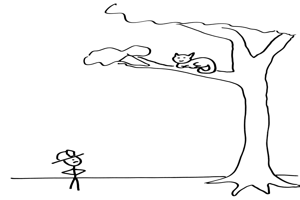

elephants.jpeg


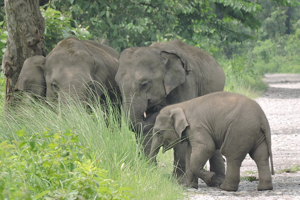

jetpack.jpg


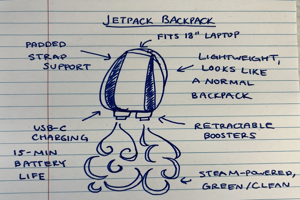

In [ ]:
import PIL.Image
from IPython.display import display

for img_filename in img_filenames:
    print(img_filename)
    display(PIL.Image.open(img_filename).resize((300, 200)))

The async code uses the `aio.interactions.create` method to invoke the API. Most async API methods can be found in the [`aio`](https://googleapis.github.io/python-genai/genai.html#genai.client.AsyncClient) namespace.

Note that this code is not run in parallel. The async call indicates that the event loop *can* yield to other tasks, but there are no other tasks scheduled in this code. This may be sufficient, e.g. if you are running this in a web server request handler as it will allow the handler to yield to other tasks while waiting for the API response.

In [16]:
import PIL
import base64
from io import BytesIO

async def describe_local_images():

  for img_filename in img_filenames:

    # Convert image to base64 for the API
    img = PIL.Image.open(img_filename)
    buffered = BytesIO()
    img.save(buffered, format="JPEG")
    img_b64 = base64.b64encode(buffered.getvalue()).decode("utf-8")

    interaction = await client.aio.interactions.create(
        model=MODEL_ID,
        input=[
            {"type": "image", "data": img_b64, "mime_type": "image/jpeg"},
            {"type": "text", "text": prompt},
        ],
    )
    print(interaction.steps[-1].content[0].text)


await describe_local_images()

/usr/local/google/home/giom/nb-fixes/venv/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3746: UserWarning: Async interactions client cannot use aiohttp, fallingback to httpx.
  await eval(code_obj, self.user_global_ns, self.user_ns)


Cat in tree.


Wild elephant family


Jetpack backpack sketch


## Downloading images asynchronously and in parallel

This example shows a more real-world case where an image is downloaded from an external source using the async HTTP library [`aiohttp`](https://pypi.org/project/aiohttp), and each image is processed in parallel.

In [18]:
import io, aiohttp, asyncio

async def download_image(session: aiohttp.ClientSession, img_url: str) -> bytes:
  """Returns base64-encoded image data from the provided URL."""
  async with session.get(img_url) as img_resp:
    data = await img_resp.read()
    return base64.b64encode(data).decode("utf-8")


async def process_image(img_future: asyncio.Future) -> str:
  """Summarise the image using the Interactions API."""
  img_b64 = await img_future
  interaction = await client.aio.interactions.create(
      model=MODEL_ID,
      input=[
          {"type": "image", "data": img_b64, "mime_type": "image/jpeg"},
          {"type": "text", "text": prompt},
      ],
  )
  return interaction.steps[-1].content[0].text

In [19]:
async def download_and_describe():

  async with aiohttp.ClientSession() as sesh:
    response_futures = []
    for img_filename in img_filenames:

      # Create the image download tasks (this does not schedule them yet).
      img_future = download_image(sesh, img_dir + img_filename)

      # Kick off the Gemini API request using the pending image download tasks.
      text_future = process_image(img_future)

      # Save the reference so they can be processed as they complete.
      response_futures.append(text_future)

    print(f"Download and content generation queued for {len(response_futures)} images.")

    # Process responses as they complete (may be a different order). The tasks are started here.
    for response in asyncio.as_completed(response_futures):
      print()
      print(await response)


await download_and_describe()

Download and content generation queued for 3 images.



Jetpack backpack sketch



Wild elephant family

Firefighter rescues cat


In the above example, a coroutine is created for each image that both downloads and then summarizes the image. The coroutines are executed in the final step, in the `as_completed` loop. To start them as early as possible without blocking the other work, you could wrap `download_image` in [`asyncio.ensure_future`](https://docs.python.org/3/library/asyncio-future.html#asyncio.ensure_future), but for this example the execution has been deferred to keep the creation and execution concerns separate.

## Next Steps

* Check out the [`AsyncClient`](https://googleapis.github.io/python-genai/genai.html#genai.client.AsyncClient) class in the Python SDK reference.
* Read more on Python's [`asyncio`](https://docs.python.org/3/library/asyncio.html) library